# **Lab 06 - Transformers**
-------
**Estudiante:** Atzel Alan Cervantes Torres 
**Materia:** Inteligencia Artificial II  
**Carrera:** Ingeniería en Ciencias de la Computación  
**Universidad:** USFX

## **Celda 1 – Setup del entorno**

En esta celda:
- Importamos librerías principales (PyTorch, torchvision, numpy, matplotlib, seaborn, sklearn).
- Fijamos la semilla para reproducibilidad.
- Detectamos el dispositivo (GPU o CPU).
- Mostramos información básica de PyTorch y CUDA para confirmar que la GPU está disponible.


In [4]:
#@title Celda 1 - Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# reproducibilidad
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch version:", torch.__version__)
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("total memory (GB):", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 2))


torch version: 2.0.1+cu118
device: cuda
gpu: NVIDIA GeForce RTX 3060 Laptop GPU
total memory (GB): 6.0


## **Celda 2 – Exploracion del dataset**

En esta celda:
- Se listan las carpetas dentro de `A:\dataResiduos` (cada carpeta corresponde a una clase).
- Se cuenta cuantas imagenes hay en cada clase.
- Se muestra la distribucion en forma de tabla y grafico de barras.
- Se visualizan algunas imagenes al azar de distintas clases para confirmar la estructura.


clases encontradas: ['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella']

numero de imagenes por clase:
barbijos: 10050
boligrafos: 11931
cds_dvds: 10028
restos_cigarros: 13153
tapas_botella: 10263


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11704\2659051236.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="crest")


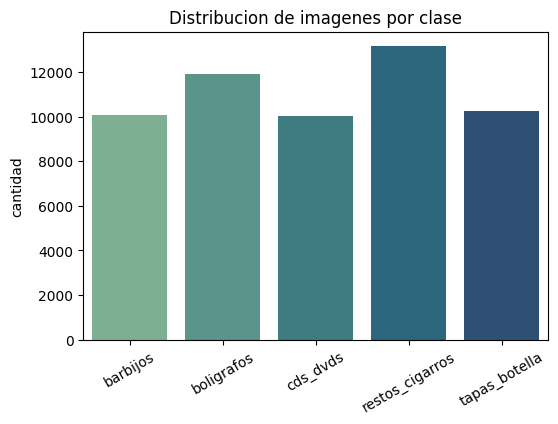

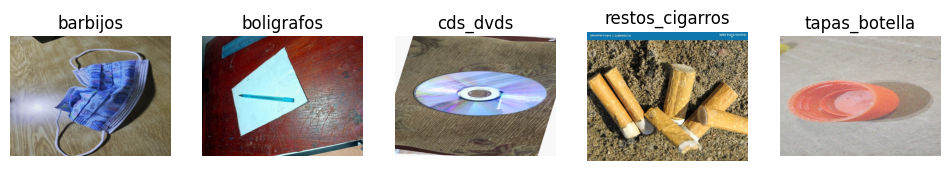

In [59]:
#@title Celda 2 - Exploracion del dataset
import os
from pathlib import Path
from PIL import Image
import random

dataDir = Path(r"A:\dataResiduos")

# listar clases
classes = [d.name for d in dataDir.iterdir() if d.is_dir()]
print("clases encontradas:", classes)

# contar imagenes por clase
counts = {cls: len(list((dataDir/cls).glob("*"))) for cls in classes}
print("\nnumero de imagenes por clase:")
for cls, n in counts.items():
    print(f"{cls}: {n}")

# grafico de barras
plt.figure(figsize=(6,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="crest")
plt.title("Distribucion de imagenes por clase")
plt.ylabel("cantidad")
plt.xticks(rotation=30)
plt.show()

# mostrar algunas imagenes al azar (1 por clase)
plt.figure(figsize=(12,6))
for i, cls in enumerate(classes):
    imgPath = random.choice(list((dataDir/cls).glob("*")))
    img = Image.open(imgPath).convert("RGB")
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls)
plt.show()


## **Celda 3 – Preprocesamiento del dataset**

En esta celda:
- Se definen las transformaciones para train, validacion y test.
  - Todas las imagenes se redimensionan a 224x224 para que el modelo sea manejable en la GPU de 6GB.
  - En train se aplican aumentos: flips, cambios de color, recortes aleatorios.
  - En val/test solo se reescala y normaliza.
- Se usa `torchvision.datasets.ImageFolder` para cargar las carpetas.
- Se divide el dataset en 70% entrenamiento, 15% validacion y 15% prueba usando `random_split`.
- Se imprimen las dimensiones finales de cada particion.


In [6]:
#@title Celda 3 - Preprocesamiento
from torchvision import datasets
from torch.utils.data import random_split

imgSize = 224

# transformaciones
trainTfms = T.Compose([
    T.Resize((imgSize, imgSize)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

testTfms = T.Compose([
    T.Resize((imgSize, imgSize)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# dataset completo
fullDs = datasets.ImageFolder(root=dataDir, transform=trainTfms)

# tamanos
nTotal = len(fullDs)
nTrain = int(0.7 * nTotal)
nVal   = int(0.15 * nTotal)
nTest  = nTotal - nTrain - nVal

trainDs, valDs, testDs = random_split(fullDs, [nTrain, nVal, nTest])

# actualizar transforms para val/test
valDs.dataset.transform = testTfms
testDs.dataset.transform = testTfms

print("total imagenes:", nTotal)
print("train:", len(trainDs))
print("val:", len(valDs))
print("test:", len(testDs))


total imagenes: 55421
train: 38794
val: 8313
test: 8314


## **Celda 4 – DataLoaders**

En esta celda:
- Se crean los `DataLoader` para train, val y test.
- Se usa `batch_size = 32` para no saturar la GPU RTX 3060 (6 GB).
- Se activan `pin_memory=True` y `num_workers=2` (valor seguro en Windows).
- Se imprime la forma de un batch de train para confirmar que las imagenes se cargan como `[batch, 3, 224, 224]` y las etiquetas corresponden.


In [7]:
#@title Celda 4 - DataLoaders
from torch.utils.data import DataLoader

batchSize = 32

trainLoader = DataLoader(trainDs, batch_size=batchSize, shuffle=True,
                         num_workers=2, pin_memory=True)

valLoader = DataLoader(valDs, batch_size=batchSize, shuffle=False,
                       num_workers=2, pin_memory=True)

testLoader = DataLoader(testDs, batch_size=batchSize, shuffle=False,
                        num_workers=2, pin_memory=True)

# verificar un batch
xb, yb = next(iter(trainLoader))
print("batch shape:", xb.shape)
print("labels shape:", yb.shape)
print("primeras etiquetas:", yb[:10].tolist())


batch shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
primeras etiquetas: [0, 3, 1, 3, 3, 0, 2, 3, 3, 1]


## **Celda 5 – Definicion del modelo Encoder**

En esta celda se definen las clases principales del encoder:
- `PositionalEncoding`: codificacion posicional sinusoidal para que el modelo distinga posiciones.
- `MultiHeadAttention`: implementa la atencion escalada por producto punto con multiples cabezas.
- `FeedForward`: MLP interno del encoder (dos capas lineales con activacion GELU).
- `EncoderLayer`: un bloque con atencion + feedforward + residual + norm.
- `TransformerEncoder`: apila N capas de `EncoderLayer` y aplica un clasificador final.

Adaptaciones para imagenes:
- Las imagenes 224x224 se dividen en parches 16x16 → 14x14=196 parches por imagen.
- Cada parche se proyecta a un vector de dimension `dModel=256`.
- Se aplica codificacion posicional y varias capas de encoder.
- La salida se promedia (mean pooling) y se pasa a una capa lineal de 5 clases.


In [9]:
#@title Celda 5 - Definicion del modelo Encoder
import math

class PositionalEncoding(nn.Module):
    def __init__(self, dModel, maxLen=5000):
        super().__init__()
        pe = torch.zeros(maxLen, dModel)
        position = torch.arange(0, maxLen, dtype=torch.float).unsqueeze(1)
        divTerm = torch.exp(torch.arange(0, dModel, 2).float() * (-math.log(10000.0) / dModel))
        pe[:, 0::2] = torch.sin(position * divTerm)
        pe[:, 1::2] = torch.cos(position * divTerm)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, dModel, numHeads):
        super().__init__()
        assert dModel % numHeads == 0
        self.dModel = dModel
        self.numHeads = numHeads
        self.dHead = dModel // numHeads

        self.qLinear = nn.Linear(dModel, dModel)
        self.kLinear = nn.Linear(dModel, dModel)
        self.vLinear = nn.Linear(dModel, dModel)
        self.outLinear = nn.Linear(dModel, dModel)

    def forward(self, q, k, v):
        B = q.size(0)
        q = self.qLinear(q).view(B, -1, self.numHeads, self.dHead).transpose(1,2)
        k = self.kLinear(k).view(B, -1, self.numHeads, self.dHead).transpose(1,2)
        v = self.vLinear(v).view(B, -1, self.numHeads, self.dHead).transpose(1,2)

        scores = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(self.dHead)
        attn = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn, v)
        context = context.transpose(1,2).contiguous().view(B, -1, self.dModel)
        return self.outLinear(context)

class FeedForward(nn.Module):
    def __init__(self, dModel, hiddenDim, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dModel, hiddenDim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hiddenDim, dModel),
            nn.Dropout(drop)
        )
    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, dModel, numHeads, hiddenDim, drop=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(dModel, numHeads)
        self.norm1 = nn.LayerNorm(dModel)
        self.ff = FeedForward(dModel, hiddenDim, drop)
        self.norm2 = nn.LayerNorm(dModel)

    def forward(self, x):
        attnOut = self.mha(x, x, x)
        x = self.norm1(x + attnOut)
        ffOut = self.ff(x)
        x = self.norm2(x + ffOut)
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, imgSize=224, patchSize=16, dModel=256,
                 numHeads=8, numLayers=6, hiddenDim=512, numClasses=5, drop=0.1):
        super().__init__()
        assert imgSize % patchSize == 0
        self.numPatches = (imgSize // patchSize) ** 2
        self.patchDim = 3 * patchSize * patchSize
        self.dModel = dModel

        self.patchEmbed = nn.Linear(self.patchDim, dModel)
        self.posEnc = PositionalEncoding(dModel, maxLen=self.numPatches)
        self.layers = nn.ModuleList([
            EncoderLayer(dModel, numHeads, hiddenDim, drop) for _ in range(numLayers)
        ])
        self.norm = nn.LayerNorm(dModel)
        self.classifier = nn.Linear(dModel, numClasses)

        self.patchSize = patchSize

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patchSize
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0,2,1,3,4).contiguous().view(B, -1, self.patchDim)

        x = self.patchEmbed(x)
        x = self.posEnc(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)

        x = x.mean(dim=1)
        return self.classifier(x)

# instanciar el modelo
model = TransformerEncoder(imgSize=224, patchSize=16, dModel=256,
                           numHeads=8, numLayers=6, hiddenDim=512,
                           numClasses=len(classes)).to(device)

# imprimir parametros
nParams = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parametros: {nParams/1e6:.2f}M")


TransformerEncoder(
  (patchEmbed): Linear(in_features=768, out_features=256, bias=True)
  (posEnc): PositionalEncoding()
  (layers): ModuleList(
    (0-5): 6 x EncoderLayer(
      (mha): MultiHeadAttention(
        (qLinear): Linear(in_features=256, out_features=256, bias=True)
        (kLinear): Linear(in_features=256, out_features=256, bias=True)
        (vLinear): Linear(in_features=256, out_features=256, bias=True)
        (outLinear): Linear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (norm): 

Iniciando visualizacion dinamica de la red neuronal...


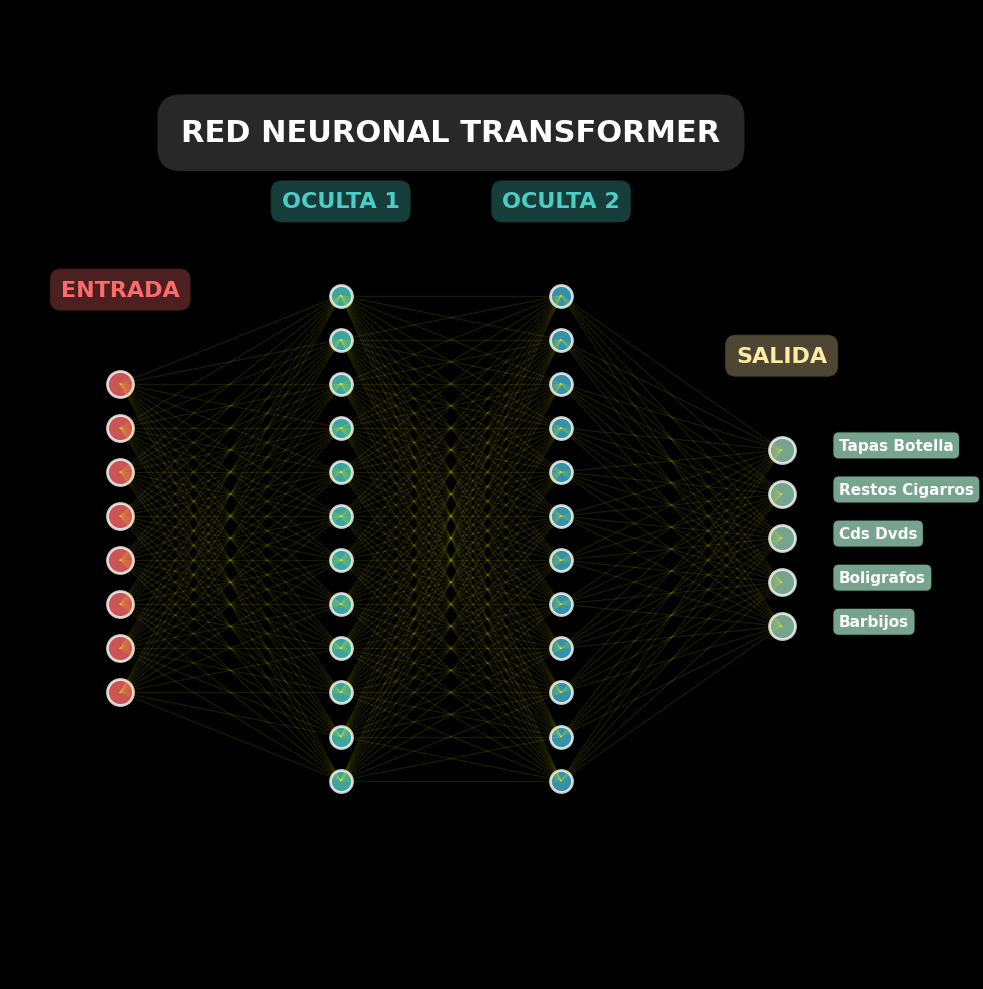

In [57]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
import numpy as np

def draw_animated_network(neurons_per_layer, class_names, interval=700, save=False):
    G = nx.DiGraph()
    pos = {}
    node_count = 0

    # crear nodos por capa con mejor posicionamiento más ancho
    for i, n_neurons in enumerate(neurons_per_layer):
        # centrar nodos verticalmente
        start_y = -(n_neurons - 1) / 2
        for j in range(n_neurons):
            G.add_node(node_count, layer=i)
            pos[node_count] = (i * 5, start_y + j)  # aún más espacio horizontal
            node_count += 1

    # crear edges entre capas consecutivas
    edges_data = []
    for n1, attr1 in G.nodes(data=True):
        for n2, attr2 in G.nodes(data=True):
            if attr2["layer"] == attr1["layer"] + 1:
                G.add_edge(n1, n2)
                edges_data.append((n1, n2, attr1["layer"]))

    # configurar figura con estilo moderno y más ancho
    fig, ax = plt.subplots(figsize=(20, 10), facecolor='black')
    ax.set_facecolor('black')
    ax.set_aspect('equal')
    ax.axis('off')

    # colores dinámicos para nodos por capa
    layer_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    # dibujar nodos con diferentes tamaños y colores por capa
    for layer in range(len(neurons_per_layer)):
        layer_nodes = [n for n, attr in G.nodes(data=True) if attr["layer"] == layer]
        node_color = layer_colors[layer % len(layer_colors)]
        node_size = 350 if layer == 0 or layer == len(neurons_per_layer)-1 else 250
        
        nx.draw_networkx_nodes(G, pos, nodelist=layer_nodes, 
                             node_size=node_size, node_color=node_color, 
                             alpha=0.8, ax=ax, edgecolors='white', linewidths=2)

    # título principal sin emojis - movido más arriba
    ax.text(len(neurons_per_layer) * 2.5 - 2.5, neurons_per_layer[0]/2 + 5, 
           "RED NEURONAL TRANSFORMER", fontsize=22, ha="center", 
           color="white", fontweight="bold",
           bbox=dict(boxstyle="round,pad=0.8", facecolor="#333333", alpha=0.8))

    # etiquetas de capas con mejor estilo sin emojis
    for i in range(len(neurons_per_layer)):
        y_center = 0  # centro vertical
        if i == 0:
            ax.text(i * 5, y_center + neurons_per_layer[i]/2 + 1.5, "ENTRADA", 
                   fontsize=16, ha="center", color="#FF6B6B", fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="#FF6B6B", alpha=0.3))
        elif i == len(neurons_per_layer)-1:
            ax.text(i * 5, y_center + neurons_per_layer[i]/2 + 1.5, "SALIDA", 
                   fontsize=16, ha="center", color="#FFEAA7", fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFEAA7", alpha=0.3))
            
            # etiquetas individuales de cada nodo de salida
            salida_nodes = [n for n, attr in G.nodes(data=True) if attr["layer"] == i]
            for idx, node in enumerate(salida_nodes):
                x, y = pos[node]
                class_name = class_names[idx].replace('_', ' ').title()
                ax.text(x + 1.3, y, class_name, fontsize=11, ha="left", 
                       color="white", fontweight="bold",
                       bbox=dict(boxstyle="round,pad=0.4", facecolor=layer_colors[i % len(layer_colors)], alpha=0.8))
        else:
            ax.text(i * 5, y_center + neurons_per_layer[i]/2 + 1.5, f"OCULTA {i}", 
                   fontsize=16, ha="center", color="#4ECDC4", fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="#4ECDC4", alpha=0.3))

    # inicializar todas las conexiones como transparentes
    edge_artists = []
    for n1, n2, layer in edges_data:
        x1, y1 = pos[n1]
        x2, y2 = pos[n2]
        line = ax.plot([x1, x2], [y1, y2], color='yellow', alpha=0.1, linewidth=1)[0]
        edge_artists.append((line, layer))

    # contador de frame para efectos
    frame_count = 0
    
    def update(frame):
        nonlocal frame_count
        frame_count += 1
        
        # capa activa con ciclo suave
        current_layer = frame % (len(neurons_per_layer) - 1)
        
        # efecto de pulso suave
        pulse = (np.sin(frame_count * 0.3) + 1) / 2  # oscila entre 0 y 1
        
        for line, layer in edge_artists:
            if layer == current_layer:
                # conexiones activas con efecto de pulso y gradiente
                intensity = 0.6 + 0.4 * pulse
                line.set_alpha(intensity)
                line.set_color('#FF1744')  # rojo vibrante
                line.set_linewidth(2.5 + pulse)
            elif layer == (current_layer - 1) % (len(neurons_per_layer) - 1):
                # conexiones de la capa anterior con desvanecimiento
                line.set_alpha(0.4)
                line.set_color('#FF9800')  # naranja
                line.set_linewidth(2)
            else:
                # conexiones inactivas
                line.set_alpha(0.1)
                line.set_color('#FFC107')  # amarillo tenue
                line.set_linewidth(1)
        
        # texto dinámico de estado sin emojis
        status_text = f"PROCESANDO CAPA {current_layer + 1}/{len(neurons_per_layer)-1}"
        if hasattr(update, 'status_artist'):
            update.status_artist.remove()
        update.status_artist = ax.text(len(neurons_per_layer) * 2.5 - 2.5, 
                                     -neurons_per_layer[0]/2 - 2.5, status_text,
                                     fontsize=14, ha="center", color="cyan", 
                                     fontweight="bold",
                                     bbox=dict(boxstyle="round,pad=0.5", facecolor="cyan", alpha=0.2))
        
        # efecto de partículas (puntos que se mueven por las conexiones activas)
        if hasattr(update, 'particles'):
            for particle in update.particles:
                particle.remove()
        
        update.particles = []
        
        for line, layer in edge_artists:
            if layer == current_layer and np.random.random() < 0.4:
                # crear partícula que se mueve por la conexión
                x_data, y_data = line.get_data()
                if len(x_data) == 2:
                    # posición aleatoria a lo largo de la línea
                    t = np.random.random()
                    x_particle = x_data[0] + t * (x_data[1] - x_data[0])
                    y_particle = y_data[0] + t * (y_data[1] - y_data[0])
                    
                    # partículas más grandes y variadas
                    particle_size = 25 + 15 * np.random.random()
                    particle_colors = ['white', '#FFE082', '#81C784', '#64B5F6']
                    particle_color = np.random.choice(particle_colors)
                    
                    particle = ax.scatter(x_particle, y_particle, c=particle_color, 
                                        s=particle_size, alpha=0.9, marker='o', 
                                        edgecolors='white', linewidths=1)
                    update.particles.append(particle)
        
        return [line for line, _ in edge_artists] + getattr(update, 'particles', [])

    # inicializar atributos para el update
    update.particles = []
    
    # crear animación más fluida
    ani = animation.FuncAnimation(fig, update, frames=200,  # más frames para suavidad
                                  interval=interval//2, blit=False, repeat=True)

    # ajustar límites para mejor visualización más ancha
    ax.set_xlim(-2.5, (len(neurons_per_layer)-1) * 5 + 3.5)
    ax.set_ylim(-max(neurons_per_layer)/2 - 4, max(neurons_per_layer)/2 + 6)

    if save:
        ani.save("animated_network_enhanced.gif", writer="pillow", fps=10)
        print("Animacion mejorada guardada como animated_network_enhanced.gif")
    else:
        plt.tight_layout()
        plt.show()
    
    return ani

# === ejemplo con efectos mejorados sin emojis ===
classes = ["barbijos", "boligrafos", "cds_dvds", "restos_cigarros", "tapas_botella"]
print("Iniciando visualizacion dinamica de la red neuronal...")
ani = draw_animated_network([8, 12, 12, len(classes)], class_names=classes, interval=1000, save=False)

## **Celda 6 – Funciones auxiliares**

En esta celda:
- Se definen funciones para ejecutar una epoca de entrenamiento y una de validacion.
- Se usa `tqdm` para mostrar **una sola barra de progreso** por epoca.
- Se calcula la perdida (loss) y la precision (accuracy).
- Se implementa un mecanismo de **guardar el mejor modelo** basado en la perdida de validacion.


In [11]:
#@title Celda 6 - Funciones auxiliares
from tqdm.auto import tqdm

def accTop1(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def trainEpoch(model, loader, optimizer, criterion, device):
    model.train()
    runningLoss, runningAcc, total = 0.0, 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batchSize = xb.size(0)
        runningLoss += loss.item() * batchSize
        runningAcc  += accTop1(logits, yb) * batchSize
        total += batchSize

        pbar.set_postfix(loss=f"{runningLoss/total:.4f}", acc=f"{runningAcc/total:.4f}")

    return runningLoss/total, runningAcc/total

def evalEpoch(model, loader, criterion, device):
    model.eval()
    runningLoss, runningAcc, total = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            batchSize = xb.size(0)
            runningLoss += loss.item() * batchSize
            runningAcc  += accTop1(logits, yb) * batchSize
            total += batchSize

    return runningLoss/total, runningAcc/total


## **Celda 7 – Entrenamiento del modelo**

En esta celda:
- Se definen el criterio de perdida (`CrossEntropyLoss`), el optimizador (`AdamW`) y un scheduler (coseno con warmup).
- Se entrena el modelo por varias epocas, mostrando una sola barra de progreso por epoca.
- Se calcula la perdida y accuracy en train y val.
- Se guarda el mejor modelo como `best_encoder_residuos.pt` basado en la menor perdida de validacion.


In [12]:
#@title Celda 7 - Entrenamiento del modelo
import os
from torch.optim.lr_scheduler import CosineAnnealingLR

# hiperparametros
numEpochs = 10
lr = 3e-4
weightDecay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weightDecay)
scheduler = CosineAnnealingLR(optimizer, T_max=numEpochs)

bestValLoss = float("inf")
outDir = "./"
bestPath = os.path.join(outDir, "best_encoder_residuos.pt")

history = {"epoch":[], "trainLoss":[], "trainAcc":[], "valLoss":[], "valAcc":[]}

for epoch in range(1, numEpochs+1):
    print(f"\nEpoch {epoch}/{numEpochs}")
    trLoss, trAcc = trainEpoch(model, trainLoader, optimizer, criterion, device)
    vaLoss, vaAcc = evalEpoch(model, valLoader, criterion, device)

    scheduler.step()

    history["epoch"].append(epoch)
    history["trainLoss"].append(trLoss)
    history["trainAcc"].append(trAcc)
    history["valLoss"].append(vaLoss)
    history["valAcc"].append(vaAcc)

    print(f"train loss={trLoss:.4f}, acc={trAcc:.4f} | val loss={vaLoss:.4f}, acc={vaAcc:.4f}")

    if vaLoss < bestValLoss:
        bestValLoss = vaLoss
        torch.save({"model": model.state_dict(),
                    "classes": classes,
                    "imgSize": imgSize}, bestPath)
        print(f"→ mejor modelo guardado en {bestPath}")



Epoch 1/10


train loss=0.4525, acc=0.8384 | val loss=0.2129, acc=0.9331
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 2/10


train loss=0.1700, acc=0.9448 | val loss=0.1545, acc=0.9485
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 3/10


train loss=0.1292, acc=0.9578 | val loss=0.1694, acc=0.9450

Epoch 4/10


train loss=0.0916, acc=0.9700 | val loss=0.0823, acc=0.9738
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 5/10


...

train loss=0.0349, acc=0.9892 | val loss=0.0386, acc=0.9874
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 7/10


train loss=0.0179, acc=0.9947 | val loss=0.0271, acc=0.9922
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 8/10


train loss=0.0079, acc=0.9979 | val loss=0.0342, acc=0.9893

Epoch 9/10


train loss=0.0029, acc=0.9993 | val loss=0.0120, acc=0.9968
→ mejor modelo guardado en ./best_encoder_residuos.pt

Epoch 10/10


train loss=0.0006, acc=0.9999 | val loss=0.0115, acc=0.9971
→ mejor modelo guardado en ./best_encoder_residuos.pt


## **Celda 8 – Evaluacion final en el set de prueba**

En esta celda:
- Se carga el mejor modelo guardado durante el entrenamiento.
- Se evalua en el conjunto de prueba.
- Se calcula la accuracy final.
- Se genera la matriz de confusion y el classification report (precision, recall, f1 por clase).


Accuracy en test: 0.9959


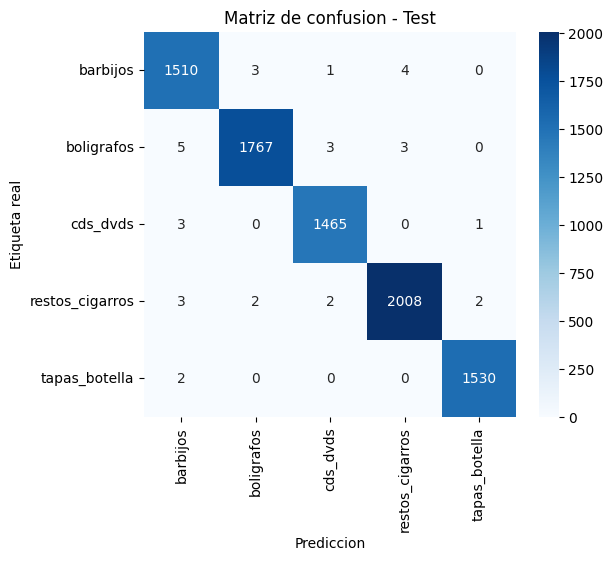


Classification Report:

                 precision    recall  f1-score   support

       barbijos       0.99      0.99      0.99      1518
     boligrafos       1.00      0.99      1.00      1778
       cds_dvds       1.00      1.00      1.00      1469
restos_cigarros       1.00      1.00      1.00      2017
  tapas_botella       1.00      1.00      1.00      1532

       accuracy                           1.00      8314
      macro avg       1.00      1.00      1.00      8314
   weighted avg       1.00      1.00      1.00      8314



In [13]:
#@title Celda 8 - Evaluacion final
# cargar mejor modelo
checkpoint = torch.load("best_encoder_residuos.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

# evaluacion en test
allLabels, allPreds = [], []
with torch.no_grad():
    for xb, yb in testLoader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(1)
        allLabels.extend(yb.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

allLabels = np.array(allLabels)
allPreds = np.array(allPreds)

# accuracy
accTest = (allLabels == allPreds).mean()
print(f"Accuracy en test: {accTest:.4f}")

# matriz de confusion
cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Prediccion")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusion - Test")
plt.show()

# classification report
print("\nClassification Report:\n")
print(classification_report(allLabels, allPreds, target_names=classes))


## **Celda 9 – Graficas de entrenamiento**

En esta celda:
- Se grafican las curvas de perdida (loss) en train y validacion.
- Se grafican las curvas de accuracy en train y validacion.
- Esto permite evaluar si hubo sobreajuste o si el modelo generaliza bien.


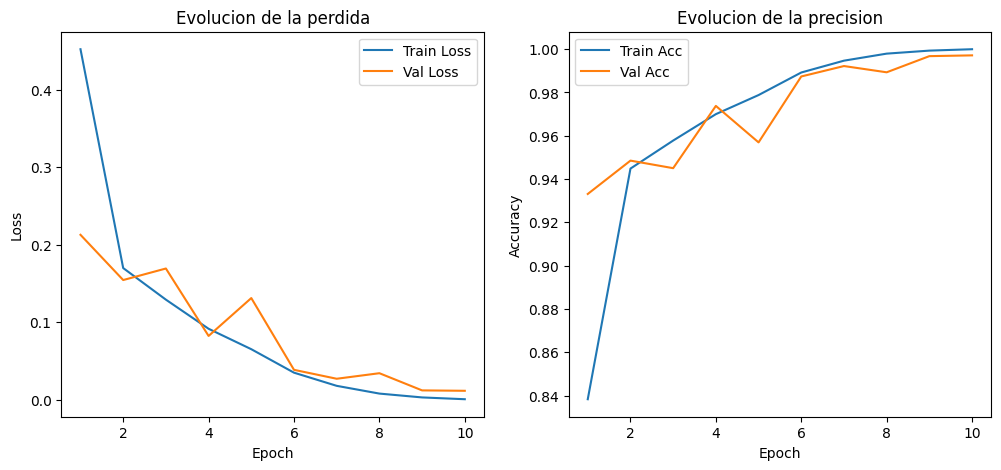

In [14]:
#@title Celda 9 - Graficas de entrenamiento
plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history["epoch"], history["trainLoss"], label="Train Loss")
plt.plot(history["epoch"], history["valLoss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolucion de la perdida")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history["epoch"], history["trainAcc"], label="Train Acc")
plt.plot(history["epoch"], history["valAcc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolucion de la precision")
plt.legend()

plt.show()


## **Celda 10 – Visualizacion de predicciones individuales**

En esta celda:
- Se seleccionan imagenes al azar del set de prueba.
- Se muestran junto a su etiqueta real y la prediccion del modelo.
- Se imprimen tambien las probabilidades de cada clase para confirmar la seguridad de la prediccion.


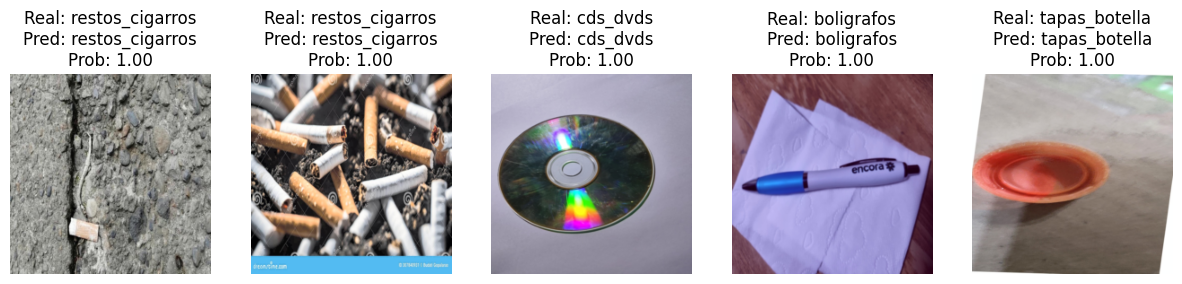

In [15]:
#@title Celda 10 - Visualizacion de predicciones
import torch.nn.functional as F

def showPredictions(model, loader, classes, numImages=5):
    model.eval()
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(1)

    plt.figure(figsize=(15,6))
    for i in range(numImages):
        plt.subplot(1, numImages, i+1)
        img = xb[i].cpu().permute(1,2,0).numpy()
        img = (img * np.array([0.229, 0.224, 0.225]) + 
                     np.array([0.485, 0.456, 0.406]))
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.axis("off")
        real = classes[yb[i].item()]
        pred = classes[preds[i].item()]
        prob = probs[i][preds[i]].item()
        plt.title(f"Real: {real}\nPred: {pred}\nProb: {prob:.2f}")

    plt.show()

# mostrar 5 imagenes al azar
showPredictions(model, testLoader, classes, numImages=5)


## **Celda 11 – Guardado final del modelo entrenado**

En esta celda:
- Se guarda el mejor modelo entrenado en la ruta especificada localmente.
- Esto permite reutilizarlo sin tener que reentrenar.


In [16]:
#@title Celda 11 - Guardado final
savePath = r"C:\USFX - CICO\USFX-CICO\5TO Semestre\Inteligencia Artificial I\SIS_420_INTELIGENCIA_ARTIFICIAL\IA_02\Lab_06\modelLab06.pt"

torch.save({
    "model": model.state_dict(),
    "classes": classes,
    "imgSize": imgSize
}, savePath)

print(f"Modelo guardado en: {savePath}")


Modelo guardado en: C:\USFX - CICO\USFX-CICO\5TO Semestre\Inteligencia Artificial I\SIS_420_INTELIGENCIA_ARTIFICIAL\IA_02\Lab_06\modelLab06.pt


## **Celda 12 – Prediccion en imagen local o desde la web**

En esta celda:
- Se carga el modelo guardado desde la ruta local.
- Se define una funcion que permite predecir una imagen:
  - Si se pasa una ruta local, se abre directamente.
  - Si se pasa una URL, se descarga y se procesa.
- Se muestra la imagen junto con la prediccion de clase y la probabilidad.


In [52]:
#@title Celda 12 - Prediccion en imagen local o desde la web
from PIL import Image
import requests
from io import BytesIO

# cargar modelo guardado
checkpoint = torch.load(r"C:\USFX - CICO\USFX-CICO\5TO Semestre\Inteligencia Artificial I\SIS_420_INTELIGENCIA_ARTIFICIAL\IA_02\Lab_06\modelLab06\modelLab06.pt", 
                        map_location=device)
model.load_state_dict(checkpoint["model"])
classes = checkpoint["classes"]
imgSize = checkpoint["imgSize"]
model.to(device)
model.eval()

def predictImage(path=None, url=None):
    # cargar imagen local o desde web
    if path:
        img = Image.open(path).convert("RGB")
    elif url:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        raise ValueError("Debes especificar path local o url")

    # preprocesar
    transform = T.Compose([
        T.Resize((imgSize, imgSize)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    x = transform(img).unsqueeze(0).to(device)

    # prediccion
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        predIdx = probs.argmax().item()
        predClass = classes[predIdx]
        prob = probs[predIdx].item()

    # mostrar imagen
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediccion: {predClass} ({prob:.2f})")
    plt.show()

    return predClass, prob

# Ejemplo de uso:
# predictImage(path=r"A:\dataResiduos\barbijos\ejemplo.jpg")
# predictImage(url="https://upload.wikimedia.org/.../ejemplo.jpg")


🚀 Función de predicción mejorada lista para usar!
💡 Usa: predictImage(path='ruta/local') o predictImage(url='http://...')


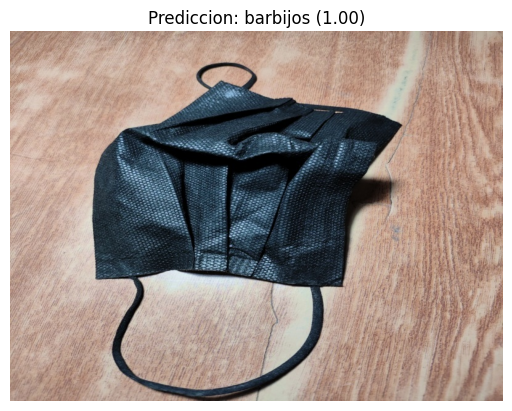

('barbijos', 0.9999532699584961)

In [20]:
predictImage(path=r"A:\ResiduosSolidosData\barbijos\__tmp__0a62b3950e514735a3f8b27beaafd267.jpg")

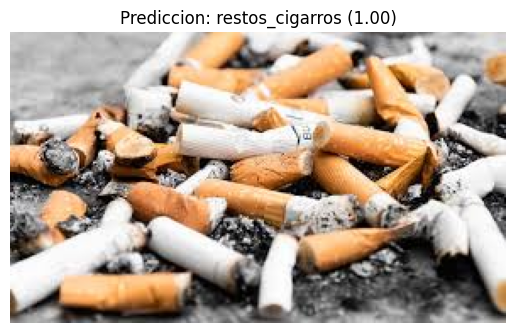

('restos_cigarros', 0.9999943971633911)

In [21]:
predictImage(url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1vDUK6tY_CSBBOTt_2gV12BAr9sxk1xGc-w&s")

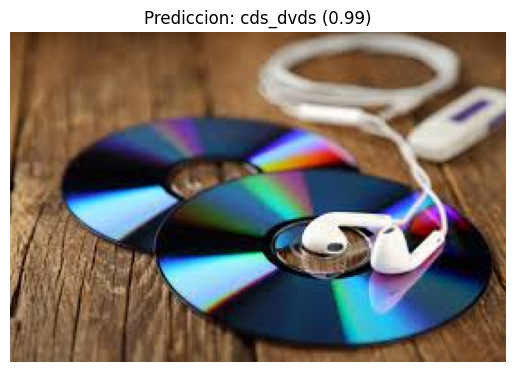

('cds_dvds', 0.9910833835601807)

In [26]:
predictImage(url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRwcbcbqSOc-X0lltfjkdMtC8uJRUz57Q4a2A&s")

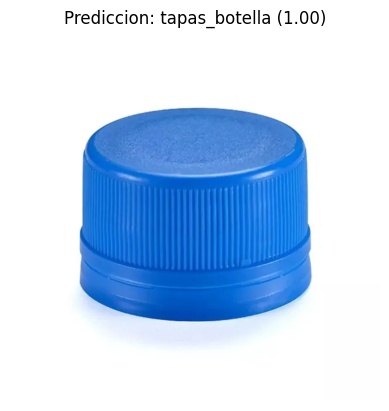

('tapas_botella', 0.9983968138694763)

In [24]:
predictImage(url="https://image.made-in-china.com/365f3j00nSeomfPYLTkF/Tapa-de-botella-de-pl-stico-blanca-y-azul-de-alta-calidad-Pco-1810-1881-Precio-est-ndar-internacional.webp")

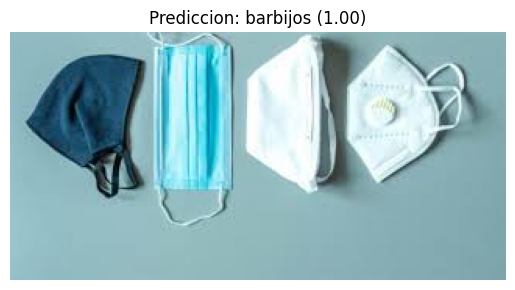

('barbijos', 0.9997912049293518)

In [36]:
predictImage(url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT_OkXEB5OdyWoKh34u2Co4u953IthSVpEfPg&s")

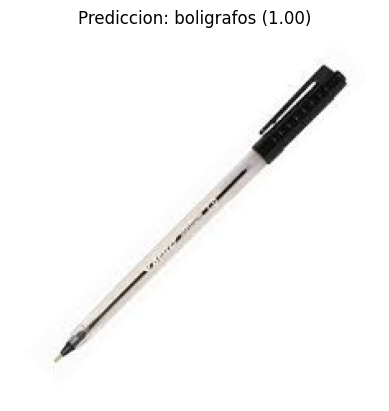

('boligrafos', 0.9999382495880127)

In [35]:
predictImage(url="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSJ-Ky0QO1Fod93IpYkyYzjFDxNCXaGRsacPA&s")

## **Celda 13 – Menu interactivo para predicciones**

En esta celda:
- Se ofrece un menu simple en consola para elegir entre:
  1. Ruta local (path).
  2. URL desde la web.
- Se llama a la funcion `predictImage` definida antes para mostrar la imagen y su prediccion.


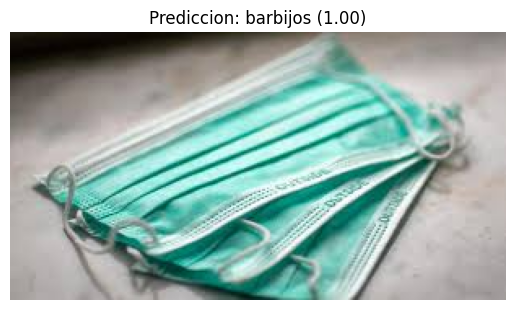

Prediccion final: barbijos (1.00)


In [41]:
#@title Celda 13 - Menu interactivo de prediccion

choice = input("Quieres usar una imagen local (L) o de la web (W)? [L/W]: ").strip().lower()

if choice == "l":
    path = input("Ingresa la ruta local de la imagen: ").strip()
    predClass, prob = predictImage(path=path)
    print(f"Prediccion final: {predClass} ({prob:.2f})")

elif choice == "w":
    url = input("Ingresa la URL de la imagen: ").strip()
    predClass, prob = predictImage(url=url)
    print(f"Prediccion final: {predClass} ({prob:.2f})")

else:
    print("Opcion no valida. Usa 'L' para local o 'W' para web.")
